<a href="https://colab.research.google.com/github/TrungCun/speaker_recognition/blob/main/code/similarity_vector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cosine Similarity With Embedding Vectors

**Author:** [TRUNG_GIAP](https://github.com/TrungCun)<br>
**Description:** This is a system that where speaker similarity is measured by cosine similarity beetwen embedding vectors 128 dimentions. The system can be used for many tasks, including speaker identification, verification, and clustering..

## Introduction

This example demonstrates how to create a model to classify speakers obtained via Mel Frequency Cepstral Coefficients (MFCC).

It shows the following:

- How to use a pre-trained model to extract an embedding vector.
- How to identify speakers with cosine similarity.

Our process:

- We prepare a dataset of speech samples from different speakers, with the speaker as the label.
- We take the MFCC of these samples.
- We use a pre-trained model to extract an embedding vector that has 128 dimensions.
- We save a few embedding vectors into the database as vector identities for the speaker.
- We test with test cases created by 3 any audio files of the same speaker.

Get the data from [FSDD](https://github.com/Jakobovski/free-spoken-digit-dataset)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls drive/MyDrive/dataset/

audio_digit.zip  AudioMNIST.zip  FSDD.zip  noise.zip


In [ ]:
!unzip drive/MyDrive/dataset/FSDD.zip

Archive:  drive/MyDrive/dataset/FSDD.zip
   creating: FSDD/
   creating: FSDD/audio/
   creating: FSDD/audio/george/
  inflating: FSDD/audio/george/0_george_0.wav  
  inflating: FSDD/audio/george/0_george_1.wav  
  inflating: FSDD/audio/george/0_george_10.wav  
  inflating: FSDD/audio/george/0_george_11.wav  
  inflating: FSDD/audio/george/0_george_12.wav  
  inflating: FSDD/audio/george/0_george_13.wav  
  inflating: FSDD/audio/george/0_george_14.wav  
  inflating: FSDD/audio/george/0_george_15.wav  
  inflating: FSDD/audio/george/0_george_16.wav  
  inflating: FSDD/audio/george/0_george_17.wav  
  inflating: FSDD/audio/george/0_george_18.wav  
  inflating: FSDD/audio/george/0_george_19.wav  
  inflating: FSDD/audio/george/0_george_2.wav  
  inflating: FSDD/audio/george/0_george_20.wav  
  inflating: FSDD/audio/george/0_george_21.wav  
  inflating: FSDD/audio/george/0_george_22.wav  
  inflating: FSDD/audio/george/0_george_23.wav  
  inflating: FSDD/audio/george/0_george_24.wav  
  in

In [ ]:
!unzip drive/MyDrive/dataset/noise.zip

Archive:  drive/MyDrive/dataset/noise.zip
   creating: noise/
   creating: noise/other/
  inflating: noise/other/exercise_bike.wav  
  inflating: noise/other/pink_noise.wav  
   creating: noise/_background_noise_/
  inflating: noise/_background_noise_/10convert.com_Audience-Claps_daSG5fwdA7o.wav  
  inflating: noise/_background_noise_/doing_the_dishes.wav  
  inflating: noise/_background_noise_/dude_miaowing.wav  
  inflating: noise/_background_noise_/running_tap.wav  


## Setup

In [ ]:
import os
import numpy as np
import librosa
import pandas as pd
import keras
import random
from keras.models import Model


In [ ]:
DATA_TEST_PATH = "/content/FSDD/audio/"

# The sampling rate to use.
# This is the one used in all the audio samples.
SAMPLING_RATE = 8000

# Parameter of MFCC
N_MFCC = 13
MAX_LEN = 20
N_FFT = 512

## Data preparation

The dataset is composed of 6 folders for 6 different speakers. Each folder contains 500 audio files (50 of each digit per speaker).
- This origin file in the folder has been sampled at 8000 Hz.
- More information about this dataset is in `metadata.py`.

we have the following directory structure:
```
data/
...speaker_01/
...speaker_02/
...speaker_03/
...speaker_04/
...speaker_05/
...speaker_06/
```

Noise preparation


In [ ]:
import IPython.display as ipd

DATA_NOISE_PATH = "/content/noise/"

noise_path = []
for subdir in os.listdir(DATA_NOISE_PATH):
  subdir_path = DATA_NOISE_PATH + subdir
  if os.path.isdir(subdir_path):
    noise_path += [
        os.path.join(subdir_path, filepath)
        for filepath in os.listdir(subdir_path)
        if filepath.endswith(".wav")
    ]
print(noise_path)

command = (
    "for dir in `ls -1 " + DATA_NOISE_PATH + "`; do "
    "for file in `ls -1 " + DATA_NOISE_PATH + "/$dir/*.wav`; do "
    "sample_rate=`ffprobe -hide_banner -loglevel panic -show_streams "
    "$file | grep sample_rate | cut -f2 -d=`; "
    "if [ $sample_rate -ne 16000 ]; then "
    "ffmpeg -hide_banner -loglevel panic -y "
    "-i $file -ar 8000 temp.wav; "
    "mv temp.wav $file; "
    "fi; done; done"
)
os.system(command)

['/content/noise/_background_noise_/dude_miaowing.wav', '/content/noise/_background_noise_/doing_the_dishes.wav', '/content/noise/_background_noise_/running_tap.wav', '/content/noise/_background_noise_/10convert.com_Audience-Claps_daSG5fwdA7o.wav', '/content/noise/other/pink_noise.wav', '/content/noise/other/exercise_bike.wav']


0

In [ ]:
def wav2mfcc(file_path, n_mfcc=N_MFCC, max_len=MAX_LEN):
    wave, sr = librosa.load(file_path, mono=True, sr=None)
    mfcc = librosa.feature.mfcc(y = wave, sr=SAMPLING_RATE, n_mfcc=n_mfcc, n_fft = N_FFT)
    if (max_len > mfcc.shape[1]):
        pad_width = max_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        mfcc = mfcc[:, :max_len]
    return mfcc

def wav_noise2mfcc(file_path, noise_path, noise_factor, n_mfcc=N_MFCC, max_len=MAX_LEN):
    wave, sr = librosa.load(file_path, mono=True, sr=None)
    noise_wave, noise_sr = librosa.load(noise_path, mono=True, sr=None)
    if len(noise_wave) < len(wave):
      noise_wave = np.pad(noise_wave, (0, len(wave) - len(noise_wave)), 'wrap')
    else:
      noise_wave = noise_wave[:len(wave)]

    combined_wave = wave + noise_wave * noise_factor
    mfcc = librosa.feature.mfcc(y = combined_wave, sr=SAMPLING_RATE, n_mfcc=n_mfcc, n_fft = N_FFT)
    if (max_len > mfcc.shape[1]):
        pad_width = max_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        mfcc = mfcc[:, :max_len]
    return mfcc

In [ ]:
import random
index_sample = random.sample(range(1, 50), 1)
digit_sample = random.sample(range(0, 10), 1)
name_sample = random.sample(os.listdir(DATA_TEST_PATH), 1)
print(digit_sample, name_sample, index_sample)
PATH = f"{DATA_TEST_PATH}{name_sample[0]}/{digit_sample[0]}_{name_sample[0]}_{index_sample[0]}.wav"
wave, sr = librosa.load(PATH, mono=True, sr=None)
print(len(wave))
ipd.Audio(wave, rate=sr)

[4] ['lucas'] [48]
4895


In [ ]:
noise = noise_path[random.randint(0, len(noise_path)-1)]
print(noise)
noise_wave, noise_sr = librosa.load(noise, mono=True, sr=None)
if len(noise_wave) < len(wave):
  noise_wave = np.pad(noise_wave, (0, len(wave) - len(noise_wave)), 'wrap')
else:
  noise_wave = noise_wave[:len(wave)]
print(noise_wave)
ipd.Audio(noise_wave, rate=sr)

/content/noise/_background_noise_/10convert.com_Audience-Claps_daSG5fwdA7o.wav
[-0.00880432  0.01863098  0.02822876 ...  0.00457764 -0.02685547
 -0.01445007]


In [ ]:
noise_scale = 0.2
combined_wave = wave + noise_wave * noise_scale
ipd.Audio(combined_wave, rate=sr)

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
librosa.display.waveshow(wave, sr=sr)
plt.title('Waveform of wave')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid()


plt.subplot(2, 1, 2)
librosa.display.waveshow(combined_wave, sr=sr)
plt.title('Waveform of combined_wave')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid()


plt.tight_layout()
plt.show()

In [ ]:
# Define the model
model_128 = keras.models.load_model('/content/drive/MyDrive/model_id_vector/model.keras')
for i, layer in enumerate(model_128.layers):
    if hasattr(layer, 'output_shape'):
        print(f"Layer {i}: {layer.name} - {layer.output_shape}")
    else:
        print(f"Layer {i}: {layer.name} - (No output_shape available)")

Layer 0: input - (No output_shape available)
Layer 1: conv2d - (No output_shape available)
Layer 2: batch_normalization - (No output_shape available)
Layer 3: activation - (No output_shape available)
Layer 4: max_pooling2d - (No output_shape available)
Layer 5: dropout - (No output_shape available)
Layer 6: conv2d_1 - (No output_shape available)
Layer 7: batch_normalization_1 - (No output_shape available)
Layer 8: activation_1 - (No output_shape available)
Layer 9: max_pooling2d_1 - (No output_shape available)
Layer 10: dropout_1 - (No output_shape available)
Layer 11: conv2d_2 - (No output_shape available)
Layer 12: batch_normalization_2 - (No output_shape available)
Layer 13: activation_2 - (No output_shape available)
Layer 14: max_pooling2d_2 - (No output_shape available)
Layer 15: dropout_2 - (No output_shape available)
Layer 16: flatten - (No output_shape available)
Layer 17: dense - (No output_shape available)
Layer 18: batch_normalization_3 - (No output_shape available)
Layer 19

In [ ]:
intermediate_layer_model = Model(inputs=model_128.input, outputs=model_128.layers[19].output)

## Create Identity Vector

- Choose the first file of each digit of all speakers to define the identity vector.
- Each speaker has 10 identity vectors for 10 digits.

In [ ]:
from statistics import mean

vector_file = 'vector.csv'

with open(vector_file, 'w') as f:
    f.write('Name,Digit,Vector\n')

for name in os.listdir(DATA_TEST_PATH):
  for digit in range(0, 10):
    id_vector = []
    FILE_PATH = f"{DATA_TEST_PATH}{name}/{digit}_{name}_0.wav"
    mfcc = wav2mfcc(FILE_PATH)
    mfcc = mfcc.reshape((1, N_MFCC, MAX_LEN, 1))
    id_vector = intermediate_layer_model.predict(mfcc)
    df = pd.DataFrame([[name,digit, id_vector]], columns=['Name', 'Digit', 'Vector']).to_csv(vector_file, mode='a', header=False, index=False)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━

In [ ]:
from numpy.linalg import norm

# Cosine similarity for two vectors, value between [0;1]
def cosine_similarity(predict, name, digit):
  file_path = '/content/vector.csv'
  df = pd.read_csv(file_path)
  result = df[(df['Name'] == name) & (df['Digit'] == digit)]
  vector_id = result['Vector'].values[0]
  vector_id = np.fromstring(vector_id[2:-2], dtype=float, sep='  ')
  cosine = np.dot(vector_id,predict)/(norm(vector_id)*norm(predict))
  return cosine


## Testing
- A test case are created by 3 random files of a speaker's use `random.sample`.
- Config minimun value of cosine similarity with parameter `max_cosine`.



---


Testing with a test case showing full cosine similarity with all identity vectors in database.

In [ ]:
import random


index_sample = random.sample(range(1, 50), 3)
digit_sample = random.sample(range(0, 10), 3)
name_sample = random.sample(os.listdir(DATA_TEST_PATH), 1)

for i in range(3):
  print(name_sample[0], digit_sample[i], index_sample[i])
  PATH = f"{DATA_TEST_PATH}{name_sample[0]}/{digit_sample[i]}_{name_sample[0]}_{index_sample[i]}.wav"
  mfcc = wav2mfcc(PATH)
  mfcc = mfcc.reshape((1, N_MFCC, MAX_LEN, 1))
  predict = intermediate_layer_model.predict(mfcc)
  predict = predict.reshape(128)

  for name in os.listdir(DATA_TEST_PATH):
    for digit in range(0, 10):
      cosine = cosine_similarity(predict, name, digit)
      print(name, digit, "Cosine Similarity:", cosine)


nicolas 6 16
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
yweweler 0 Cosine Similarity: 0.7613016480424687
yweweler 1 Cosine Similarity: 0.7050367046651774
yweweler 2 Cosine Similarity: 0.8432717517931779
yweweler 3 Cosine Similarity: 0.721989147385663
yweweler 4 Cosine Similarity: 0.5379256999595369
yweweler 5 Cosine Similarity: 0.7898042586298335
yweweler 6 Cosine Similarity: 0.7716856287715339
yweweler 7 Cosine Similarity: 0.7597330121227255
yweweler 8 Cosine Similarity: 0.7552332634057494
yweweler 9 Cosine Similarity: 0.7275506315891097
nicolas 0 Cosine Similarity: 0.9058454589798567
nicolas 1 Cosine Similarity: 0.8710010425292105
nicolas 2 Cosine Similarity: 0.8244577924330203
nicolas 3 Cosine Similarity: 0.9069156579786308
nicolas 4 Cosine Similarity: 0.7731640738464437
nicolas 5 Cosine Similarity: 0.8470718871138888
nicolas 6 Cosine Similarity: 0.9242734278636567
nicolas 7 Cosine Similarity: 0.9053625430057183
nicolas 8 Cosine Similarity: 0.9495968918035292
nicolas 9 Cosine Similarity:

---
Testing efficiency with 100 test cases. A test case passes if true `name` of file.

In [ ]:
import random
from pydub import AudioSegment

passed_testcase = 0
total_testcase = 100

for k in range(100):

  index_sample = random.sample(range(1, 50), 3)
  digit_sample = random.sample(range(0, 10), 3)
  name_sample = random.sample(os.listdir(DATA_TEST_PATH), 1)

  audio_files = []
  max_cosine = -1
  predict_name = None

  for i in range(3):
    PATH = f"{DATA_TEST_PATH}{name_sample[0]}/{digit_sample[i]}_{name_sample[0]}_{index_sample[i]}.wav"
    audio_files.append(PATH)
    combined = AudioSegment.empty()
    for file in audio_files:
      audio_segment = AudioSegment.from_wav(file)
      combined += audio_segment

  output_file_path = "combined_audio.wav"
  combined.export(output_file_path, format="wav")
  mfcc = wav2mfcc(output_file_path)
  os.remove(output_file_path)
  audio_files.clear()

  mfcc = mfcc.reshape((1, N_MFCC, MAX_LEN, 1))
  predict = intermediate_layer_model.predict(mfcc)
  predict = predict.reshape(128)

  for name in os.listdir(DATA_TEST_PATH):
    for digit in range(0, 10):
      cosine = cosine_similarity(predict, name, digit)
      if cosine > max_cosine:
        max_cosine = cosine
        predict_name = name

  if predict_name == name_sample[0]:
    passed_testcase += 1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━

In [ ]:
acc_percent = (passed_testcase / total_testcase) * 100
print(f"Percentage of True: {acc_percent}%")

Percentage of True: 39.0%


In [ ]:
import os
import numpy as np

# Đường dẫn đến thư mục lớn
OUTPUT_FOLDER = '/content/vector_outputs'

labels = os.listdir(DATA_TEST_PATH)
for label in labels:
    LABEL_PATH = os.path.join(DATA_TEST_PATH, label)
    for wavfile in os.listdir(LABEL_PATH):
        FILE_PATH = os.path.join(LABEL_PATH, wavfile)

        # Tách tên tập tin
        name_parts = wavfile.split('_')
        index = name_parts[0]
        true_name = name_parts[1]
        digit = name_parts[2].split('.')[0]

        # Tính toán MFCC
        mfcc = wav2mfcc(FILE_PATH)
        mfcc = mfcc.reshape((1, N_MFCC, MAX_LEN, 1))
        predict = intermediate_layer_model.predict(mfcc)
        predict = predict.reshape(128)


        # Tạo thư mục cho true_name bên trong thư mục lớn
        true_name_folder = os.path.join(OUTPUT_FOLDER, true_name)
        os.makedirs(true_name_folder, exist_ok=True)

        # Lưu MFCC vào thư mục tương ứng
        vector_file_path = os.path.join(true_name_folder, f'{index}_{true_name}_{digit}.npy')
        np.save(vector_file_path, predict)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━

In [ ]:
import numpy as np
passed_testcase = 0

labels = os.listdir(OUTPUT_FOLDER)
for label in labels:
    LABEL_PATH = os.path.join(OUTPUT_FOLDER, label)
    for mfcc_file in os.listdir(LABEL_PATH):

        max_cosine = 1
        predict_name = None

        FILE_PATH = os.path.join(LABEL_PATH, mfcc_file)
        name_parts = mfcc_file.split('_')
        index = name_parts[0]
        true_name = name_parts[1]
        digit = name_parts[2].split('.')[0]

        predict = np.load(FILE_PATH)
        for name in os.listdir(DATA_TEST_PATH):
          for digit in range(0, 10):
            cosine = cosine_similarity(predict, name, digit)
            if cosine > max_cosine:
              max_cosine = cosine
              predict_name = name

        if predict_name == true_name:
          passed_testcase += 1

print(passed_testcase)

36


In [ ]:
def cosine_caculate(vector1, vector2):
    # Chuyển đổi các vector thành numpy arrays nếu chưa phải
    vector1 = np.array(vector1)
    vector2 = np.array(vector2)

    cos_sim = np.dot(vector1,vector2)/(norm(vector1)*norm(vector2))

    return cos_sim

TP = 0
TN = 0
FP = 0
FN = 0
labels = os.listdir(OUTPUT_FOLDER)
max_cosine = 0.3
for label1 in labels:
    LABEL_PATH1 = os.path.join(OUTPUT_FOLDER, label1)
    for mfcc_file1 in os.listdir(LABEL_PATH1):
      FILE_PATH1 = os.path.join(LABEL_PATH1, mfcc_file1)

      name_parts1 = mfcc_file1.split('_')
      name1 = name_parts1[1]
      predict1 = np.load(FILE_PATH1)

      for label2 in labels:
        LABEL_PATH2 = os.path.join(OUTPUT_FOLDER, label2)
        for mfcc_file2 in os.listdir(LABEL_PATH2):
          FILE_PATH2 = os.path.join(LABEL_PATH2, mfcc_file2)

          name_parts2 = mfcc_file2.split('_')
          name2 = name_parts2[1]
          predict2 = np.load(FILE_PATH2)

          cosine = cosine_caculate(predict1, predict2)


          if cosine >= max_cosine and name1 == name2:
            TP = TP + 1
          if cosine >= max_cosine and name1 != name2:
            FP = FP + 1
          if cosine < max_cosine and name1 == name2:
            FN = FN + 1
          if cosine < max_cosine and name1 != name2:
            TN = TN + 1
          print(TP, FP, FN, TN)

TPR = TP / (TP + FN)
FPR = FP / (FP + TN)
print( TPR , FPR , max_cosine)

In [ ]:
TPRs = [0.0015, 0.15, 0.53, 0.83, 0.96, 0.99, 0.99, 0.99, 1, 1, 1]
FPRs = [0.0, 0.008, 0.13, 0.39, 0.65, 0.84, 0.96, 0.99, 0.99, 1, 1]


auc = 0
for i in range(len(FPRs) - 1):
  auc += (FPRs[i + 1] - FPRs[i]) * (TPRs[i] + TPRs[i + 1]) / 2

# In ra giá trị AUC-ROC
print(f"AUC: {auc}")

In [ ]:
import matplotlib.pyplot as plt

# Vẽ biểu đồ
plt.figure(figsize=(8, 6))
plt.plot(FPRs, TPRs, marker='o', linestyle='-', color='b')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.grid()
plt.axhline(y=1, color='r', linestyle='--')
plt.axvline(x=0, color='r', linestyle='--')
plt.show()

văn bản in đậm---

Testing efficiency with 100 test cases has added noise. A test case passes if true `name` of file.

In [ ]:
import random
from pydub import AudioSegment

passed_testcase = 0
total_testcase = 100

for k in range(100):

  index_sample = random.sample(range(1, 50), 3)
  digit_sample = random.sample(range(0, 10), 3)
  name_sample = random.sample(os.listdir(DATA_TEST_PATH), 1)

  audio_files = []
  max_cosine = 0.8
  predict_name = None

  for i in range(3):
    PATH = f"{DATA_TEST_PATH}{name_sample[0]}/{digit_sample[i]}_{name_sample[0]}_{index_sample[i]}.wav"
    audio_files.append(PATH)
    combined = AudioSegment.empty()
    for file in audio_files:
      audio_segment = AudioSegment.from_wav(file)
      combined += audio_segment

  output_file_path = "combined_audio.wav"
  combined.export(output_file_path, format="wav")
  mfcc = wav_noise2mfcc(output_file_path, noise_path[random.randint(0, len(noise_path)-1)], noise_factor = 0.0)
  os.remove(output_file_path)
  audio_files.clear()

  mfcc = mfcc.reshape((1, N_MFCC, MAX_LEN, 1))
  predict = intermediate_layer_model.predict(mfcc)
  predict = predict.reshape(128)

  for name in os.listdir(DATA_TEST_PATH):
    for digit in range(0, 10):
      cosine = cosine_similarity(predict, name, digit)
      if cosine > max_cosine:
        max_cosine = cosine
        predict_name = name

  if predict_name == name_sample[0]:
    passed_testcase += 1

In [ ]:
acc_percent = (passed_testcase / total_testcase) * 100
print(f"Percentage of True: {acc_percent}%")

In [ ]:
labels = os.listdir(DATA_TEST_PATH)
passed_testcase = 0

for label in labels:
    LABEL_PATH = os.path.join(DATA_TEST_PATH, label)
    for wavfile in os.listdir(LABEL_PATH):
        max_cosine = 0.8
        predict_name = None

        FILE_PATH = os.path.join(LABEL_PATH, wavfile)

        # Tách tên tập tin
        name_parts = wavfile.split('_')
        index = name_parts[0]
        true_name = name_parts[1]
        digit = name_parts[2].split('.')[0]

        # Tính toán MFCC
        mfcc = wav_noise2mfcc(FILE_PATH, noise_path[random.randint(0, len(noise_path)-1)], noise_factor = 0.2)
        mfcc = mfcc.reshape((1, N_MFCC, MAX_LEN, 1))
        predict = intermediate_layer_model.predict(mfcc)
        predict = predict.reshape(128)


        for name in os.listdir(DATA_TEST_PATH):
          for digit in range(0, 10):
            cosine = cosine_similarity(predict, name, digit)
            if cosine > max_cosine:
              max_cosine = cosine
              predict_name = name

        if predict_name == true_name:
          passed_testcase += 1

print(passed_testcase)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━

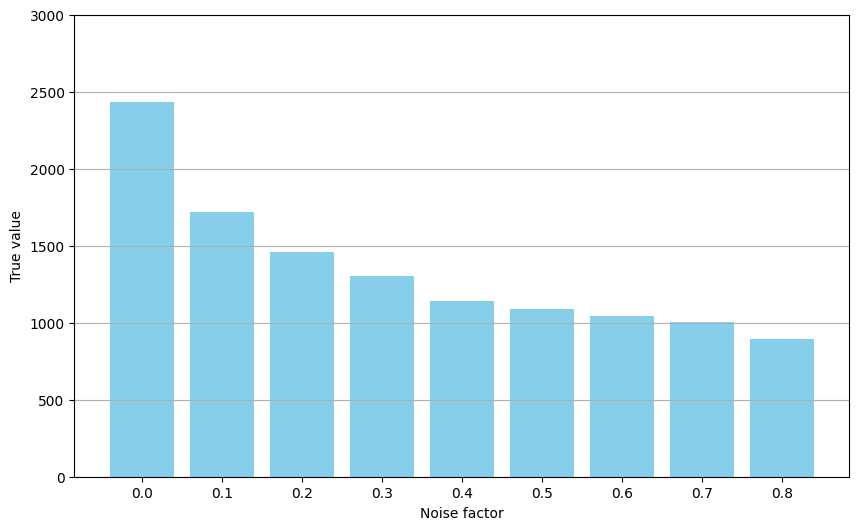

In [ ]:
import matplotlib.pyplot as plt

# Dữ liệu đã sắp xếp từ 0.0 đến 0.8
labels = ['0.0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8']
values = [2432, 1720, 1460, 1304, 1139, 1090, 1044, 1002, 892]

# Vẽ đồ thị cột
plt.figure(figsize=(10, 6))
plt.bar(labels, values, color='skyblue')
plt.ylim(0, 3000)  # Giới hạn tối đa của trục y là 3000
plt.xlabel('Noise factor')
plt.ylabel('True value')
plt.grid(axis='y')

# Hiển thị đồ thị
plt.show()